In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
search_time = pd.read_csv("search_time.csv")
collision_count = pd.read_csv("collision_count.csv")

display(search_time.head())
display(collision_count.head())

,size,algorithm,microseconds,found_count
0,100,linear_search,27,1
1,100,binary_search_tree,0,1
2,100,red_black_tree,0,1
3,100,hash_table,0,1
4,100,multimap,1,1


,size,collisions
0,100,42
1,200,86
2,500,263
3,1000,475
4,2000,728


In [ ]:
algorithm_names = {
    "linear_search": "Линейный поиск",
    "binary_search_tree": "Бинарное дерево",
    "red_black_tree": "Красно-чёрное дерево",
    "hash_table": "Хэш-таблица",
    "multimap": "std::multimap"
}

search_time["algorithm_name"] = search_time["algorithm"].map(algorithm_names)

search_time.head()

,size,algorithm,microseconds,found_count,algorithm_name
0,100,linear_search,27,1,Линейный поиск
1,100,binary_search_tree,0,1,Бинарное дерево
2,100,red_black_tree,0,1,Красно-чёрное дерево
3,100,hash_table,0,1,Хэш-таблица
4,100,multimap,1,1,std::multimap


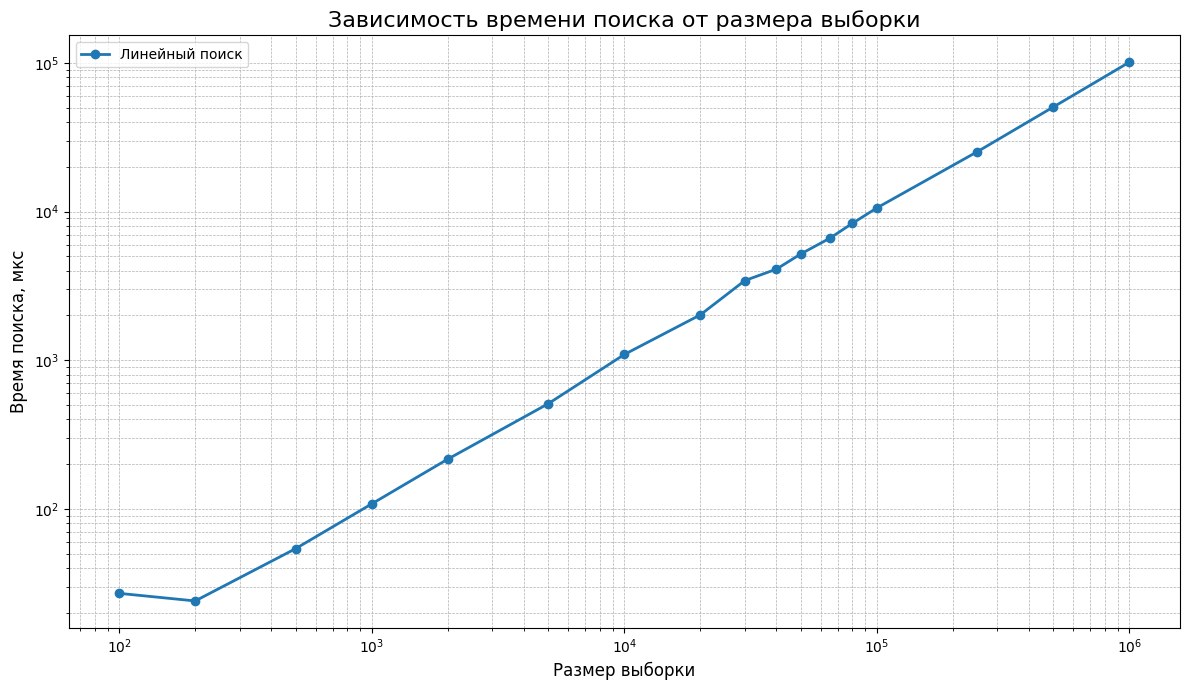

In [5]:
plt.figure(figsize=(12, 7))

data = search_time[search_time["algorithm"] == "linear_search"]
plt.plot(
    data["size"],
    data["microseconds"],
    marker="o",
    linewidth=2,
    label="Линейный поиск"
)

plt.title("Зависимость времени поиска от размера выборки", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Время поиска, мкс", fontsize=12)

plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("search_time_all_algorithms.png", dpi=300)
plt.show()

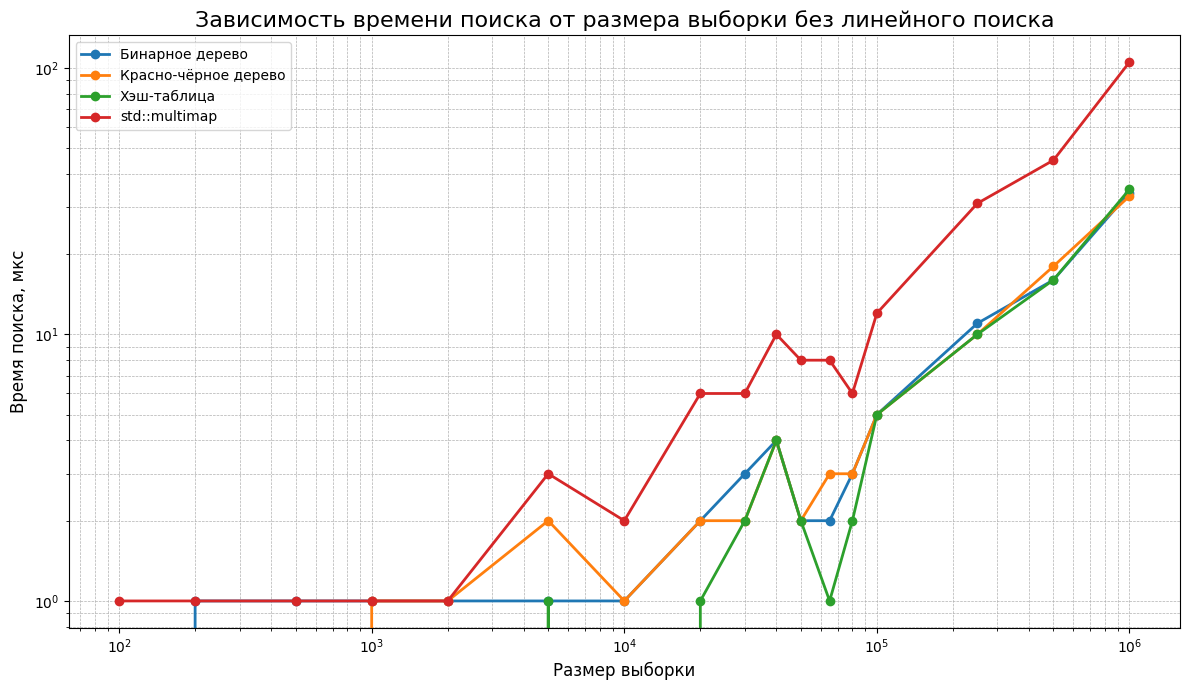

In [6]:
fast_algorithms = search_time[search_time["algorithm"] != "linear_search"]

plt.figure(figsize=(12, 7))

for algorithm in fast_algorithms["algorithm"].unique():
    data = fast_algorithms[fast_algorithms["algorithm"] == algorithm]

    plt.plot(
        data["size"],
        data["microseconds"],
        marker="o",
        linewidth=2,
        label=algorithm_names.get(algorithm, algorithm)
    )

plt.title("Зависимость времени поиска от размера выборки без линейного поиска", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Время поиска, мкс", fontsize=12)

plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("search_time_without_linear.png", dpi=300)
plt.show()

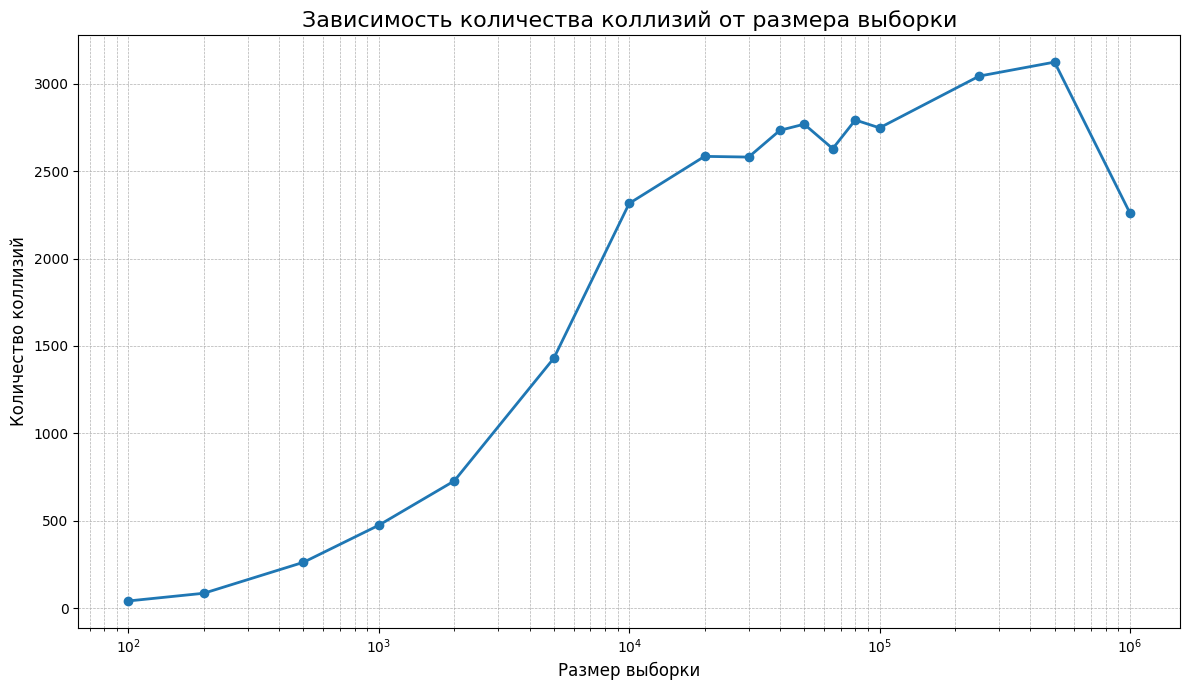

In [ ]:
plt.figure(figsize=(12, 7))

plt.plot(
    collision_count["size"],
    collision_count["collisions"],
    marker="o",
    linewidth=2
)

plt.title("Зависимость количества коллизий от размера выборки", fontsize=16)
plt.xlabel("Размер выборки", fontsize=12)
plt.ylabel("Количество коллизий", fontsize=12)

plt.xscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()

plt.savefig("hash_collisions.png", dpi=300)
plt.show()